In [5]:
def is_prime(n):
    """Bir sayının asal olup olmadığını kontrol eden fonksiyon."""
    if n < 2:
        return False
    if n in (2, 3):
        return True
    if n % 2 == 0 or n % 3 == 0:
        return False
    i = 5
    while i * i <= n:
        if n % i == 0 or n % (i + 2) == 0:
            return False
        i += 6
    return True

def count_twin_primes_in_ranges(max_limit=10_000_000, step=1_000_000):
    """Belirtilen aralıklardaki ikiz asal çiftlerini hesaplar."""
    print(f"{'Aralık':<25} | {'İkiz Asal Çifti Sayısı':<25}")
    print("-" * 55)
    
    total_twins = 0
    
    for start in range(0, max_limit, step):
        end = start + step
        twin_count = 0
        
        # İkiz asalları kontrol et (p ve p + 2)
        # Optimizasyon için alt sınır 3'ten küçükse 3'ten başlatabiliriz
        range_start = max(3, start)
        if range_start % 2 == 0:
            range_start += 1
            
        # Eğer aralık 0-1 milyon ise (3,5) çiftini kaçırmamak için özel durum
        if start == 0:
            # 3 ve 5 özel bir ikiz asaldır
            twin_count += 1
            range_start = 5
            
        # Aralık içindeki tek sayıları tara
        p = range_start
        while p < end:
            # p ve p+2 asal mı? Ayrıca p+2'nin de 'end' sınırını aşmadığından emin olalım
            if p + 2 <= end:
                if is_prime(p) and is_prime(p + 2):
                    twin_count += 1
            p += 2
            
        total_twins += twin_count
        aralik_str = f"{start:,} – {end:,}".replace(",", ".")
        print(f"{aralik_str:<25} | {twin_count:,}".replace(",", "."))
        
    print("-" * 55)
    print(f"Toplam İkiz Asal Sayısı: {total_twins:,}".replace(",", "."))

# Kodu çalıştırmak için:
if __name__ == "__main__":
    count_twin_primes_in_ranges()

Aralık                    | İkiz Asal Çifti Sayısı   
-------------------------------------------------------
0 – 1.000.000             | 8.169
1.000.000 – 2.000.000     | 6.702
2.000.000 – 3.000.000     | 6.061
3.000.000 – 4.000.000     | 5.928
4.000.000 – 5.000.000     | 5.603
5.000.000 – 6.000.000     | 5.453
6.000.000 – 7.000.000     | 5.343
7.000.000 – 8.000.000     | 5.359
8.000.000 – 9.000.000     | 5.249
9.000.000 – 10.000.000    | 5.113
-------------------------------------------------------
Toplam İkiz Asal Sayısı: 58.980


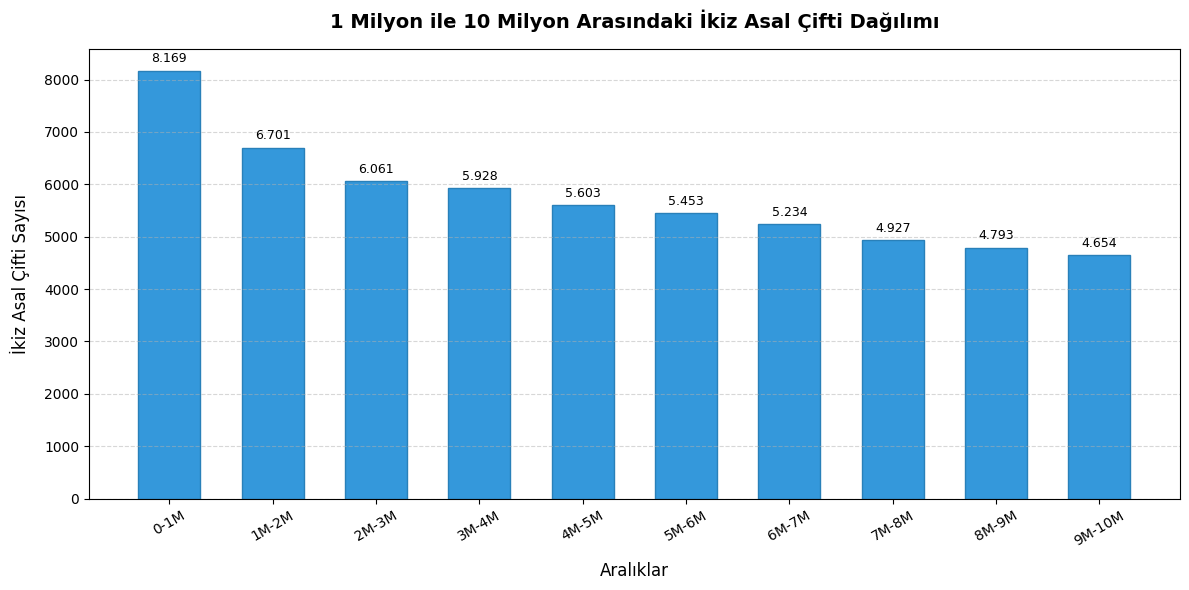

In [6]:
import matplotlib.pyplot as plt

# Aralıklar ve daha önce hesaplanan ikiz asal sayıları
araliklar = [
    '0-1M', '1M-2M', '2M-3M', '3M-4M', '4M-5M', 
    '5M-6M', '6M-7M', '7M-8M', '8M-9M', '9M-10M'
]
sayilar = [8169, 6701, 6061, 5928, 5603, 5453, 5234, 4927, 4793, 4654]

# Grafik boyutunu ayarlama
plt.figure(figsize=(12, 6))

# Sütun grafiği oluşturma
bars = plt.bar(araliklar, sayilar, color='#3498db', edgecolor='#2980b9', width=0.6)

# Grafik başlığı ve eksen etiketleri
plt.title('1 Milyon ile 10 Milyon Arasındaki İkiz Asal Çifti Dağılımı', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Aralıklar', fontsize=12, labelpad=10)
plt.ylabel('İkiz Asal Çifti Sayısı', fontsize=12, labelpad=10)

# Sütunların üzerine tam sayı değerlerini yazdırma
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2., 
        height + 100, 
        f'{height:,}'.replace(',', '.'), 
        ha='center', 
        va='bottom', 
        fontsize=9
    )

# Izgara çizgileri ve düzen
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=30)
plt.tight_layout()

# Grafiği kaydetme ve gösterme
plt.savefig('ikiz_asal_dagilimi.png', dpi=300)
plt.show()